# Clusterização de Trajetórias de Ciclones Tropicais com TRACLUS

## Dados: HURDAT2 - Oceano Atlântico (2004–2025)

---

# 1. Introdução

Este notebook implementa o **TRACLUS** (TRAjectory CLUStering) e o aplica a trajetórias de tempestades e furacões do Atlântico. O algoritmo usa um framework de **partição e agrupamento**: cada trajetória é quebrada em segmentos de reta e segmentos semelhantes, de tempestades diferentes ou de trechos diferentes da mesma tempestade. São agrupados por densidade, revelando **sub-trajetórias comuns** que passariam despercebidas ao comparar trajetórias inteiras.

**Dados:** `hurdat2_trajectories.csv` (posição, intensidade e status a cada 6h, Atlântico 2004-2025).

In [1]:
# Importações utilizadas

# Bibliotecas
import json
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy import stats
from sklearn.metrics import silhouette_samples, silhouette_score

# Módulo TRACLUS
from traclus_core import (
    RAIO_TERRA_KM, EPSILON, NAO_CLASSIFICADO, RUIDO,
    latlon_para_xy, xy_para_latlon, adicionar_mapa_base,
    comprimento, componentes_distancia, distancia_segmentos,
    custo_L, mdl_com_particao, mdl_sem_particao, particionar_trajetoria,
    calcular_matriz_distancia, entropia_vizinhanca,
    clusterizar_segmentos, filtrar_cardinalidade_trajetorias, qmeasure,
    vetor_direcao_medio, gerar_trajetoria_representativa,
    construir_perfil_meteorologico,
    calcular_coesao_clusters, calcular_separacao_clusters, davies_bouldin_adaptado,
)

## 1.1 Roteiro do notebook

| Bloco | Conteúdo |
|---|---|
| **1. Introdução** | Contexto e visão geral do TRACLUS |
| **2. Dados e pré-processamento** | HURDAT2, filtragem, EDA, conversão geográfica |
| **3. Fase 1 - Partição (MDL)** | Distâncias entre segmentos, custo MDL, algoritmo de partição |
| **4. Fase 2 - Agrupamento** | Distância entre segmentos, heurística de $\varepsilon$, clusterização, trajetória representativa |
| **5. Avaliação dos clusters** | Silhouette adaptado, QMeasure, cardinalidade, ruído |
| **6. Interpretação** | Intensidade, duração e regimes meteorológicos por cluster |

## 1.2 Visão geral do algoritmo TRACLUS

O TRACLUS tem **duas fases**:

**Fase 1 - Partição:** Cada trajetória é decomposta em segmentos de reta pelo princípio **MDL**, equilibrando *conciseness* (poucos segmentos) e *preciseness* (boa aproximação). Um algoritmo aproximado $O(n)$ escolhe pontos característicos sempre que particionar fica mais barato, em bits, do que manter a trajetória original.

**Fase 2 - Agrupamento:** Todos os segmentos formam um conjunto único $\mathcal{D}$, clusterizado por densidade com uma distância composta pelas componentes perpendicular ($d_\perp$), paralela ($d_\parallel$) e angular ($d_\theta$). Clusters válidos (cardinalidade mínima de trajetórias) recebem uma trajetória representativa via varredura (*sweep line*).

---
# 2. Dados e Pré-processamento

A base **HURDAT2** (*Hurricane Database 2*), mantida pelo National Hurricane Center (NOAA), registra a posição e a intensidade de todos os sistemas tropicais do Atlântico em intervalos de 6 horas desde 1851. O arquivo `hurdat2_trajectories.csv` contém, para os anos de **2004 a 2025**, as seguintes colunas:

| Coluna | Descrição |
|---|---|
| `storm_id` | Identificador único do sistema (ex.: `AL012004`) |
| `storm_name` | Nome do sistema |
| `datetime`, `year`, `month`, `day`, `hour`, `minute` | Data/hora da observação |
| `record_id` | Marcador de eventos especiais (landfall etc.), majoritariamente vazio |
| `status` | Classificação do sistema no momento da observação |
| `latitude`, `longitude` | Posição do centro do sistema (graus) |
| `wind_kt` | Vento máximo sustentado (nós) |
| `pressure_mb` | Pressão central mínima (hPa) |

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 6)

CAMINHO_DADOS = "dataset/hurdat2_trajectories.csv"
ESTADO_ALEATORIO = 123

pd.set_option("display.max_columns", None)

## 2.1 Carregamento e exploração inicial dos dados

In [3]:
df_bruto = pd.read_csv(CAMINHO_DADOS, parse_dates=["datetime"])

print(f"Total de registros (observações de 6h):   {len(df_bruto):,}")
print(f"Total de sistemas (storm_id) distintos:   {df_bruto['storm_id'].nunique()}")
print(f"Período coberto:                          {df_bruto['year'].min()}–{df_bruto['year'].max()}")

df_bruto.head()

Total de registros (observações de 6h):   11,885
Total de sistemas (storm_id) distintos:   388
Período coberto:                          2004–2025


,storm_id,storm_name,datetime,year,month,day,hour,minute,record_id,status,latitude,longitude,wind_kt,pressure_mb
0,AL012004,ALEX,2004-07-31 18:00:00,2004,7,31,18,0,NaN,TD,30.3,-78.3,25,1010
1,AL012004,ALEX,2004-08-01 00:00:00,2004,8,1,0,0,NaN,TD,31.0,-78.8,25,1009
2,AL012004,ALEX,2004-08-01 06:00:00,2004,8,1,6,0,NaN,TD,31.5,-79.0,25,1009
3,AL012004,ALEX,2004-08-01 12:00:00,2004,8,1,12,0,NaN,TD,31.6,-79.1,30,1009
4,AL012004,ALEX,2004-08-01 18:00:00,2004,8,1,18,0,NaN,TS,31.6,-79.2,35,1009


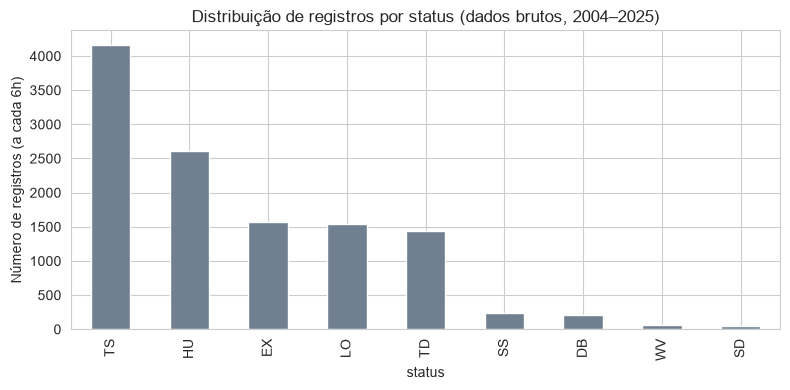

status
TS    4166
HU    2611
EX    1576
LO    1539
TD    1443
SS     233
DB     208
WV      68
SD      41
Name: count, dtype: int64

In [4]:
contagem_status = df_bruto["status"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
contagem_status.plot(kind="bar", ax=ax, color="slategray")
ax.set_title("Distribuição de registros por status (dados brutos, 2004–2025)")
ax.set_xlabel("status")
ax.set_ylabel("Número de registros (a cada 6h)")
plt.tight_layout()
plt.show()

contagem_status

**Códigos de `status` no HURDAT2:** `TD` (depressão tropical), `TS` (tempestade tropical), `HU` (furacão), `EX` (extratropical), `LO` (baixa remanescente), `SS`/`SD` (subtropical), `DB`/`WV` (perturbação/onda, pré-formação).

## 2.2 Critérios de filtragem

1. **Apenas `TS`/`HU`**: foco no comportamento de sistemas tropicais desenvolvidos, excluindo formação, dissipação e sistemas subtropicais.

2. **Duração mínima de 3 dias (12 observações a 6h)**: trajetórias mais curtas dão poucos pontos para uma partição MDL útil e tendem a virar ruído.

A filtragem é aplicada primeiro aos registros `TS`/`HU` e depois à contagem por sistema. É mantido apenas os trechos desenvolvidos de cada tempestade, não a trajetória inteira.

In [5]:
PONTOS_MINIMOS = 12
STATUS_VALIDOS = ["TS", "HU"]

# Mmanter apenas registros TS/HU
dados = df_bruto[df_bruto["status"].isin(STATUS_VALIDOS)].copy()

# Manter apenas sistemas com >= PONTOS_MINIMOS registros TS/HU
contagem_pontos = dados.groupby("storm_id").size()
tempestades_validas = contagem_pontos[contagem_pontos >= PONTOS_MINIMOS].index
dados = dados[dados["storm_id"].isin(tempestades_validas)].copy()

dados = dados.sort_values(["storm_id", "datetime"]).reset_index(drop=True)

print(f"Sistemas antes da filtragem:  {df_bruto['storm_id'].nunique()}")
print(f"Sistemas após filtragem:      {dados['storm_id'].nunique()}")
print(f"Registros antes da filtragem: {len(df_bruto):,}")
print(f"Registros após filtragem:     {len(dados):,}  "
      f"({len(dados) / len(df_bruto):.1%} do total)")

Sistemas antes da filtragem:  388
Sistemas após filtragem:      215
Registros antes da filtragem: 11,885
Registros após filtragem:     5,882  (49.5% do total)


In [6]:
# Tabela-resumo por tempestade
resumo_tempestades = dados.groupby("storm_id").agg(
    nome_tempestade=("storm_name", "first"),
    ano=("year", "first"),
    n_pontos=("latitude", "size"),
    vento_max=("wind_kt", "max"),
    vento_medio=("wind_kt", "mean"),
    pressao_min=("pressure_mb", "min"),
).reset_index()

resumo_tempestades["duracao_h"] = (resumo_tempestades["n_pontos"] - 1) * 6
resumo_tempestades["duracao_dias"] = resumo_tempestades["duracao_h"] / 24

print(f"Trajetórias finais: {len(resumo_tempestades)}")
resumo_tempestades.describe()[["n_pontos", "vento_max", "duracao_dias"]].round(2)

Trajetórias finais: 215


,n_pontos,vento_max,duracao_dias
count,215.00,215.00,215.00
mean,27.36,88.51,6.59
std,13.96,32.08,3.49
min,12.00,40.00,2.75
25%,16.00,60.00,3.75
50%,23.00,80.00,5.50
75%,36.50,112.50,8.88
max,83.00,165.00,20.50


## 2.3 Análise exploratória dos dados filtrados

Com as 215 trajetórias filtradas (5.882 pontos), examinamos três dimensões antes da etapa geométrica: distribuição de duração, de intensidade (`wind_kt`) e distribuição temporal (tempestades por ano).

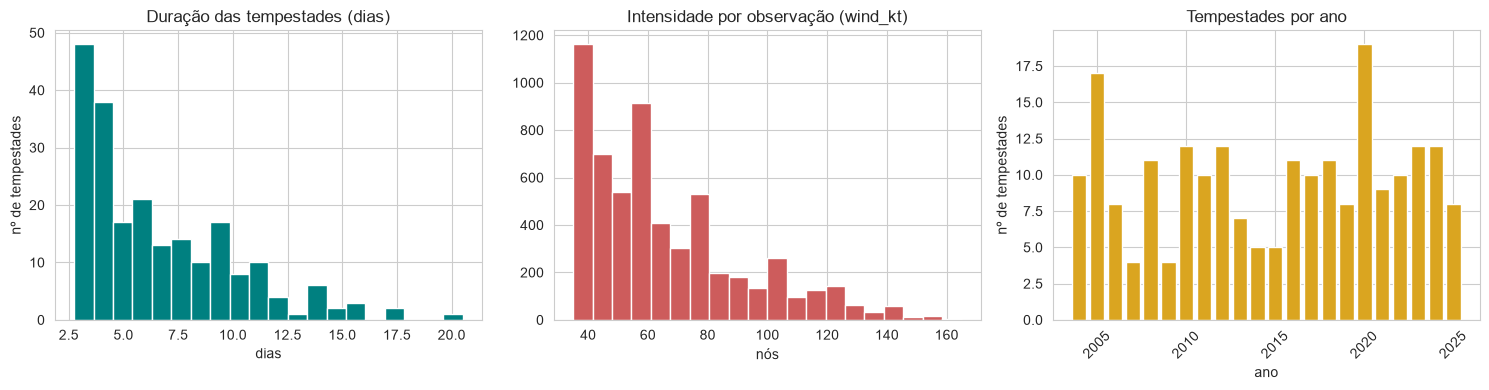

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(resumo_tempestades["duracao_dias"], bins=20, color="teal", edgecolor="white")
axes[0].set_title("Duração das tempestades (dias)")
axes[0].set_xlabel("dias")
axes[0].set_ylabel("nº de tempestades")

axes[1].hist(dados["wind_kt"], bins=20, color="indianred", edgecolor="white")
axes[1].set_title("Intensidade por observação (wind_kt)")
axes[1].set_xlabel("nós")

tempestades_por_ano = resumo_tempestades["ano"].value_counts().sort_index()
axes[2].bar(tempestades_por_ano.index, tempestades_por_ano.values, color="goldenrod")
axes[2].set_title("Tempestades por ano")
axes[2].set_xlabel("ano")
axes[2].set_ylabel("nº de tempestades")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

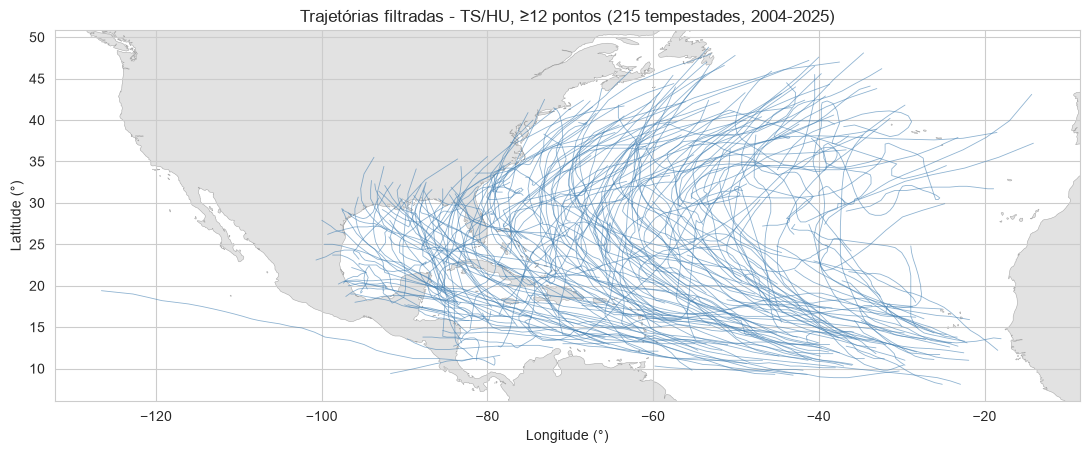

In [54]:
CAMINHO_MAPA_BASE = "dataset/mapa_base_atlantico.geojson"
# Carrega o arquivo geojson para projetar o mapa

fig, ax = plt.subplots(figsize=(11, 6))

for id_tempestade, grupo in dados.groupby("storm_id"):
    ax.plot(grupo["longitude"], grupo["latitude"], lw=0.6, alpha=0.6, color="steelblue", zorder=2)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Trajetórias filtradas - TS/HU, ≥{PONTOS_MINIMOS} pontos "
              f"({resumo_tempestades.shape[0]} tempestades, 2004-2025)")
ax.set_aspect("equal")
adicionar_mapa_base(ax)
plt.tight_layout()
plt.show()

## 2.4 Conversão de coordenadas geográficas para cartesianas

As distâncias do TRACLUS pressupõem um espaço **euclidiano plano**, mas 1° de longitude equivale a $\approx 111\cos(\text{lat})$ km enquanto 1° de latitude é sempre $\approx 111$ km. Aplicar as fórmulas direto sobre graus distorceria ângulos e distâncias.

**Solução:** projeção equirretangular com correção de cosseno, usando o centróide global do conjunto como referência $(\text{lat}_{ref}, \text{lon}_{ref})$ com $R \approx 6371$ km:

$$x = R \cdot (\text{lon} - \text{lon}_{ref}) \cdot \cos(\text{lat}_{ref}) \cdot \frac{\pi}{180}, \qquad y = R \cdot (\text{lat} - \text{lat}_{ref}) \cdot \frac{\pi}{180}$$

Ponto de referência: lat_ref = 24.16°, lon_ref = -62.87°
Extensão em x: [-6,466, 4,948] km
Extensão em y: [-1,786, 2,739] km


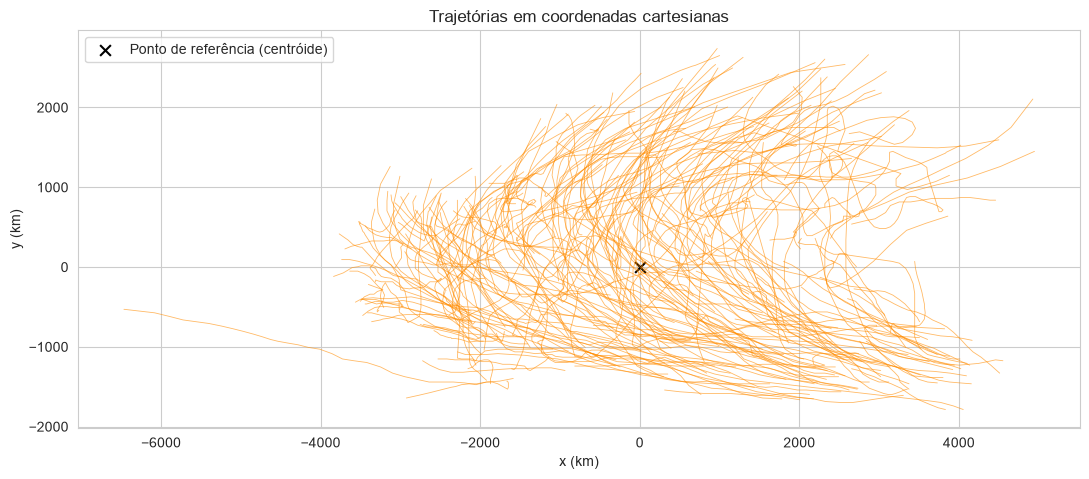

In [9]:
LAT_REF = dados["latitude"].mean()
LON_REF = dados["longitude"].mean()

dados["x_km"], dados["y_km"] = latlon_para_xy(
    dados["latitude"], dados["longitude"], LAT_REF, LON_REF
) # Transforma latitude e longitude em coordenadas (x, y) em km

print(f"Ponto de referência: lat_ref = {LAT_REF:.2f}°, lon_ref = {LON_REF:.2f}°")
print(f"Extensão em x: [{dados['x_km'].min():,.0f}, {dados['x_km'].max():,.0f}] km")
print(f"Extensão em y: [{dados['y_km'].min():,.0f}, {dados['y_km'].max():,.0f}] km")

dados[["storm_id", "latitude", "longitude", "x_km", "y_km"]].head()

# Plota o gráfico das trajetórias + centróide
fig, ax = plt.subplots(figsize=(11, 6))

for id_tempestade, grupo in dados.groupby("storm_id"):
    ax.plot(grupo["x_km"], grupo["y_km"], lw=0.6, alpha=0.6, color="darkorange")

ax.scatter([0], [0], color="black", marker="x", s=60, label="Ponto de referência (centróide)")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Trajetórias em coordenadas cartesianas")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

---
# 3. Fase 1 - Partição de Trajetórias (MDL)

Implementamos a **Fase 1** do TRACLUS: transformar cada trajetória em uma sequência de **segmentos de reta** (*trajectory partitions*).

## 3.1 Distância entre segmentos e partição por MDL

A distância entre dois segmentos $L_i=s_ie_i$ e $L_j=s_je_j$ soma três componentes, obtidas projetando $s_j,e_j$ sobre a reta de $L_i$:

$$d_\perp = \frac{l_{\perp1}^2+l_{\perp2}^2}{l_{\perp1}+l_{\perp2}}\;\text{(perp.)}, \quad d_\parallel=\min(l_{\parallel1},l_{\parallel2})\;\text{(paralela)}, \quad d_\theta = \begin{cases}\|L_j\|\sin\theta, & \theta<90°\\ \|L_j\|, & \theta\ge90°\end{cases}\;\text{(angular)}$$

A distância final é $dist(L_i,L_j)=w_\perp d_\perp+w_\parallel d_\parallel+w_\theta d_\theta$ ($w=1$), sempre com o segmento mais longo como $L_i$ (garante simetria); um piso `EPSILON` evita $\log_2(0)$.

A partição usa o princípio **MDL**, equilibrando concisão ($L(H)$) e precisão ($L(D|H)$):

$$L(H) = \sum_j \log_2\!\big(len(p_{c_j}p_{c_{j+1}})\big), \qquad L(D|H) = \sum_j\sum_k\big[\log_2(d_\perp)+\log_2(d_\theta)\big]$$

Comparamos $MDL_{par}$ (um segmento cobre a janela) com $MDL_{nopar}$ (pontos originais): se $MDL_{par}>MDL_{nopar}$, vale particionar. `vies_supressao=2.0`, somada a $MDL_{nopar}$, suprime partições curtas (evita *chaining*) e gera segmentos ~20% mais longos.

O algoritmo aproximado é $O(n)$: a janela $[p_{início},p_{atual}]$ cresce enquanto $MDL_{par}\le MDL_{nopar}$; ao falhar, o ponto **anterior** vira característico.

## 3.2 Aplicação da partição a todas as trajetórias

Aplicamos `particionar_trajetoria` às 215 trajetórias com **`VIES_SUPRESSAO = 2.0`**. Segmentos curtos têm baixa "força direcional" ($d_\theta \le \|L_j\|$), o que causa *chaining* no agrupamento por densidade; somar essa constante a $MDL_{nopar}$ suprime partições curtas.

O resultado vira a coluna `dados["ponto_caracteristico"]` e a tabela `segmentos`$\mathcal{(D)}$: uma linha por partição, com identificadores, coordenadas (km e lat/lon), comprimento, instantes e vento médio/máximo.

In [10]:
VIES_SUPRESSAO = 2.0

linhas_segmentos = []
dados["ponto_caracteristico"] = False
id_seg = 0

for id_tempestade, grupo in dados.groupby("storm_id", sort=False):
    grupo = grupo.reset_index()  # Preserva o índice original de 'dados' na coluna 'index'
    pontos_xy = grupo[["x_km", "y_km"]].values
    pontos_caracteristicos = particionar_trajetoria(pontos_xy, vies_supressao=VIES_SUPRESSAO)

    # Marca os pontos característicos no dataframe principal
    dados.loc[grupo.loc[pontos_caracteristicos, "index"], "ponto_caracteristico"] = True

    for m in range(len(pontos_caracteristicos) - 1):
        # Para cada par de pontos característicos consecutivos, cria um segmento
        i, j = pontos_caracteristicos[m], pontos_caracteristicos[m + 1]
        linhas_segmentos.append(dict(
            id_segmento=id_seg,
            id_tempestade=id_tempestade,
            idx_inicio=i, idx_fim=j,
            x_inicio=pontos_xy[i, 0], y_inicio=pontos_xy[i, 1],
            x_fim=pontos_xy[j, 0], y_fim=pontos_xy[j, 1],
            lat_inicio=grupo["latitude"].iloc[i], lon_inicio=grupo["longitude"].iloc[i],
            lat_fim=grupo["latitude"].iloc[j], lon_fim=grupo["longitude"].iloc[j],
            comprimento_km=comprimento(pontos_xy[i], pontos_xy[j]),
            datetime_inicio=grupo["datetime"].iloc[i], datetime_fim=grupo["datetime"].iloc[j],
            vento_medio=grupo["wind_kt"].iloc[i:j + 1].mean(),
            vento_max=grupo["wind_kt"].iloc[i:j + 1].max(),
        ))
        id_seg += 1

segmentos = pd.DataFrame(linhas_segmentos)

print(f"Trajetórias processadas:        {dados['storm_id'].nunique()}")
print(f"Pontos originais:               {len(dados):,}")
print(f"Pontos característicos:         {dados['ponto_caracteristico'].sum():,}")
print(f"Segmentos (partições) gerados:  {len(segmentos):,}")
print(f"Taxa de retenção de pontos:     {dados['ponto_caracteristico'].sum() / len(dados):.1%}")

segmentos.head()

Trajetórias processadas:        215
Pontos originais:               5,882
Pontos característicos:         3,643
Segmentos (partições) gerados:  3,428
Taxa de retenção de pontos:     61.9%


,id_segmento,id_tempestade,idx_inicio,idx_fim,x_inicio,y_inicio,x_fim,y_fim,lat_inicio,lon_inicio,lat_fim,lon_fim,comprimento_km,datetime_inicio,datetime_fim,vento_medio,vento_max
0,0,AL012004,0,2,-1656.900711,826.887971,-1677.191122,804.648986,31.6,-79.2,31.4,-79.4,30.104372,2004-08-01 18:00:00,2004-08-02 06:00:00,36.666667,40
1,1,AL012004,2,3,-1677.191122,804.648986,-1636.610301,793.529493,31.4,-79.4,31.3,-79.0,42.076670,2004-08-02 06:00:00,2004-08-02 12:00:00,45.000000,50
2,2,AL012004,3,4,-1636.610301,793.529493,-1606.174685,849.126957,31.3,-79.0,31.8,-78.7,63.383000,2004-08-02 12:00:00,2004-08-02 18:00:00,50.000000,50
3,3,AL012004,4,5,-1606.174685,849.126957,-1555.448658,915.843913,31.8,-78.7,32.4,-78.2,83.810990,2004-08-02 18:00:00,2004-08-03 00:00:00,55.000000,60
4,4,AL012004,5,6,-1555.448658,915.843913,-1474.287016,982.560869,32.4,-78.2,33.0,-77.4,105.063621,2004-08-03 00:00:00,2004-08-03 06:00:00,65.000000,70


## 3.3 Validação visual da partição

Comparamos trajetória original (pontos cinza) e partição obtida (segmentos azuis, pontos característicos em vermelho) para três tempestades distintas: **Emily (2011)**: curta e retilínea, forte compressão esperada; **Nadine (2012)**: longa e tortuosa (o *loop* no Atlântico central), baixa compressão esperada; **Bertha (2008)**: recurvatura, trecho sinuoso seguido de trecho retilíneo.

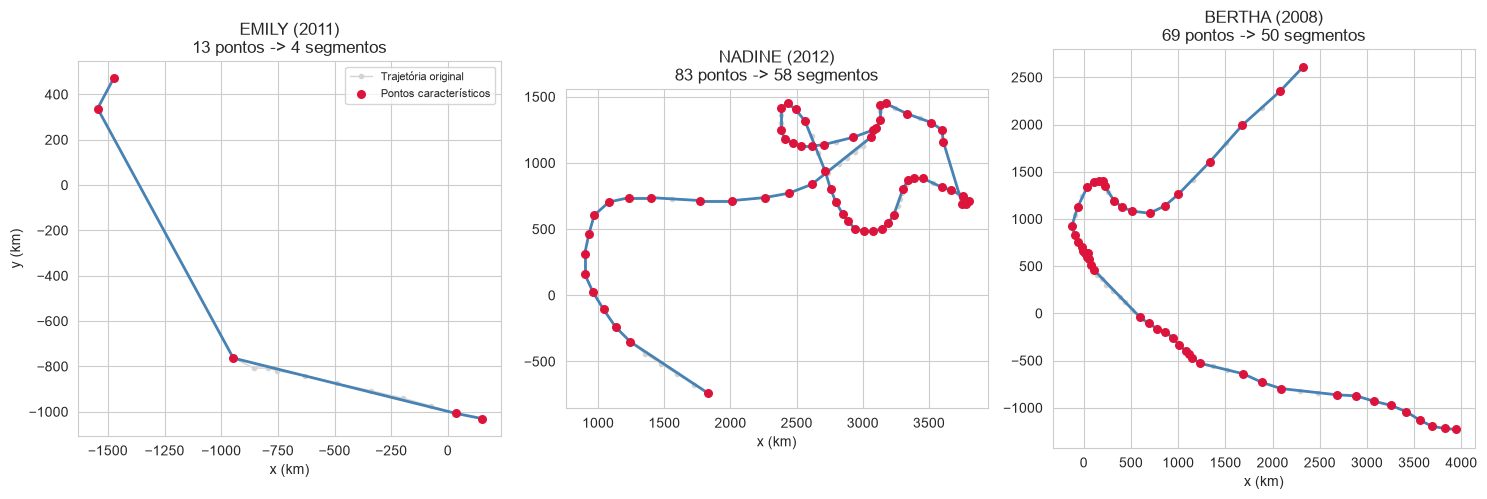

In [11]:
exemplos = ["AL052011", "AL142012", "AL022008"]  # Emily, Nadine, Bertha

fig, axes = plt.subplots(1, len(exemplos), figsize=(15, 5))
for eixo, id_tempestade in zip(axes, exemplos):
    grupo = dados[dados["storm_id"] == id_tempestade].reset_index(drop=True)
    seg_grupo = segmentos[segmentos["id_tempestade"] == id_tempestade]
    nome = grupo["storm_name"].iloc[0]
    ano = grupo["year"].iloc[0]

    eixo.plot(grupo["x_km"], grupo["y_km"], "o-", color="lightgray", ms=3, lw=1,
              label="Trajetória original", zorder=1)

    caracteristicos = grupo[grupo["ponto_caracteristico"]]
    eixo.scatter(caracteristicos["x_km"], caracteristicos["y_km"], color="crimson", s=30,
                  zorder=3, label="Pontos característicos")

    for _, linha in seg_grupo.iterrows():
        eixo.plot([linha["x_inicio"], linha["x_fim"]], [linha["y_inicio"], linha["y_fim"]],
                   color="steelblue", lw=2, zorder=2)

    eixo.set_title(f"{nome} ({ano})\n{len(grupo)} pontos -> {len(seg_grupo)} segmentos")
    eixo.set_xlabel("x (km)")
    eixo.set_aspect("equal")
    if eixo is axes[0]:
        eixo.set_ylabel("y (km)")
        eixo.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3.4 Estatísticas da partição

Olhamos para a distribuição de comprimentos dos segmentos e para quantos segmentos cada trajetória produziu.

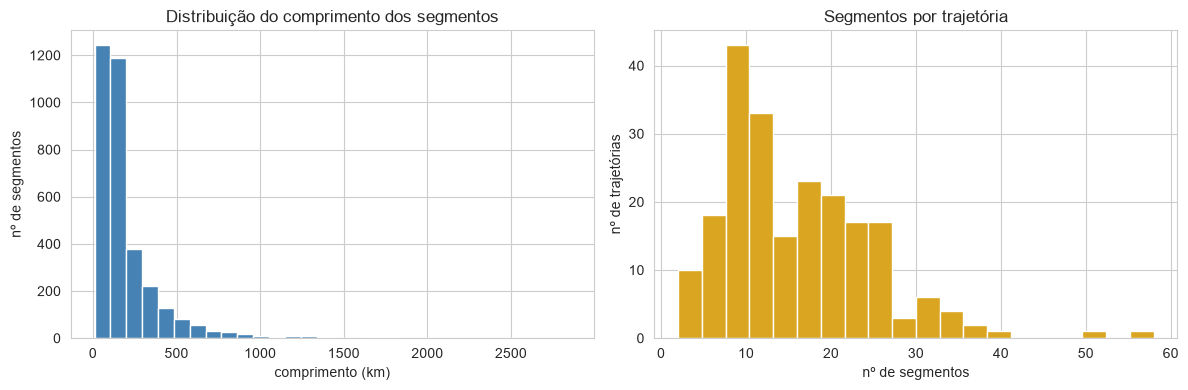

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(segmentos["comprimento_km"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribuição do comprimento dos segmentos")
axes[0].set_xlabel("comprimento (km)")
axes[0].set_ylabel("nº de segmentos")

segmentos_por_trajetoria = segmentos.groupby("id_tempestade").size()
axes[1].hist(segmentos_por_trajetoria, bins=20, color="goldenrod", edgecolor="white")
axes[1].set_title("Segmentos por trajetória")
axes[1].set_xlabel("nº de segmentos")
axes[1].set_ylabel("nº de trajetórias")

plt.tight_layout()
plt.show()

**Leitura:** A distribuição de comprimentos é assimétrica à direita. A maioria dos segmentos tem 80-200 km, mas alguns chegam a 2.850 km. O número de segmentos por trajetória varia de 2 a 58, mediana 16.

---
# 4. Fase 2 - Agrupamento de Segmentos por Densidade

Implementamos a **Fase 2** do TRACLUS: agrupar segmentos de tempestades possivelmente diferentes em **clusters**, cada um com uma trajetória representativa. Baseada no **DBSCAN** e adaptado para segmentos, com duas extensões do TRACLUS:
1. **Cardinalidade de trajetórias**: evita clusters sustentados por poucas tempestades;

2. **Trajetória representativa**: varredura/*sweep line* ao longo da direção média.

## 4.1 Matriz de distância entre segmentos

A clusterização depende de consultas de $\varepsilon$-vizinhança: $N_\varepsilon(L_i) = \{L_j \in \mathcal{D} \mid dist(L_i,L_j) \le \varepsilon\}$. Pré-computamos a **matriz de distância completa** $|\mathcal{D}|\times|\mathcal{D}|$ uma única vez e a reutilizamos em todas as etapas seguintes (heurística de $\varepsilon$, clusterização, `QMeasure`, silhouette).

In [13]:
matriz_dist = calcular_matriz_distancia(segmentos)
print(f"Matriz de distância: {matriz_dist.shape}, {matriz_dist.nbytes / 1e6:.1f} MB")
print(f"Simétrica: {np.allclose(matriz_dist, matriz_dist.T)}")

distancias_validas = matriz_dist[~np.eye(len(segmentos), dtype=bool)]
print("\nDistribuição das distâncias entre segmentos (km):")
print(pd.Series(distancias_validas).describe().round(1))

Matriz de distância: (3428, 3428), 94.0 MB
Simétrica: True

Distribuição das distâncias entre segmentos (km):
count    11747756.0
mean         3118.3
std          1800.2
min             0.0
25%          1731.2
50%          2849.7
75%          4234.4
max         16034.9
dtype: float64


## 4.2 Heurística de seleção de $\varepsilon$ (entropia)

$N_\varepsilon(L)$ é o conjunto de segmentos a distância $\le\varepsilon$ de $L$. Escolhemos o $\varepsilon$ que **minimiza a entropia** do tamanho dessas vizinhanças:

$$H(X) = -\sum_{i=1}^{n} p(x_i)\log_2 p(x_i), \qquad p(x_i) = \frac{|N_\varepsilon(x_i)|}{\sum_j|N_\varepsilon(x_j)|}$$

Se $\varepsilon$ é muito pequeno ou muito grande, todas as vizinhanças ficam do mesmo tamanho: entropia alta e sem estrutura. Numa boa clusterização há assimetria, o que **reduz** $H$. O $\varepsilon^*$ ideal é o ponto de entropia mínima. A partir dele, sugerimos `MinLns` um pouco acima da vizinhança média: $[\overline{|N_{\varepsilon^*}|}+1,\ \overline{|N_{\varepsilon^*}|}+3]$.

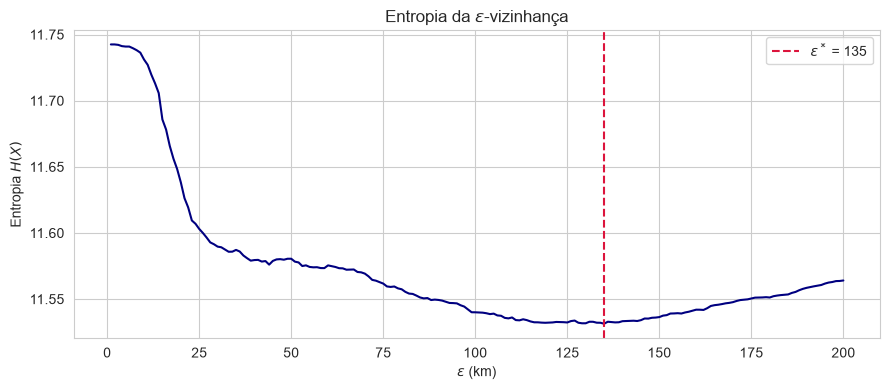

eps_otimo = 135 km, H_min = 11.5314  (log2(n) = 11.7432)
|N_eps*(L)| médio = 9.40
MinLns sugerido: 11 a 13


In [14]:
valores_eps = np.arange(1, 201)
resultado_entropia = [entropia_vizinhanca(matriz_dist, eps) for eps in valores_eps]
H = np.array([r[0] for r in resultado_entropia])
media_vizinhanca = np.array([r[1] for r in resultado_entropia])

eps_otimo = int(valores_eps[np.argmin(H)])
media_otima = media_vizinhanca[np.argmin(H)]
minlns_min, minlns_max = int(np.ceil(media_otima)) + 1, int(np.ceil(media_otima)) + 3

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(valores_eps, H, color="navy")
ax.axvline(eps_otimo, color="crimson", ls="--", label=f"$\\varepsilon^*$ = {eps_otimo}")
ax.set_xlabel(r"$\varepsilon$ (km)")
ax.set_ylabel("Entropia $H(X)$")
ax.set_title("Entropia da $\\varepsilon$-vizinhança")
ax.legend()
plt.tight_layout()
plt.show()

print(f"eps_otimo = {eps_otimo} km, H_min = {H.min():.4f}  (log2(n) = {np.log2(len(segmentos)):.4f})")
print(f"|N_eps*(L)| médio = {media_otima:.2f}")
print(f"MinLns sugerido: {minlns_min} a {minlns_max}")

## 4.3 Clusterização por densidade e escolha de parâmetros

Agrupamos os segmentos com a **mesma lógica do DBSCAN**: um segmento é "core" se tiver ao menos `MinLns` vizinhos dentro de um raio $\varepsilon$, e clusters crescem conectando segmentos densos entre si.

Duas adaptações específicas do TRACLUS:

- **Cardinalidade de trajetórias**: um cluster só é válido se reunir segmentos de pelo menos `MinLns` trajetórias *distintas*. Isso evita que poucas tempestades sustentem um cluster sozinhas;

- **Chaining**: segmentos muito curtos têm baixa força direcional ($d_\theta\le\|L_j\|$) e podem encadear erroneamente segmentos de orientações diferentes num único cluster, por isso o parâmetro `vies_supressao`.

Para escolher $\varepsilon$ e `MinLns`, fazemos uma busca em grade ao redor da região sugerida pela heurística de entropia, usando o `QMeasure` como critério.

$$QMeasure = \underbrace{\sum_{i}\frac{1}{2|C_i|}\sum_{x,y\in C_i}dist(x,y)^2}_{\text{SSE intra-cluster}} \;+\; \underbrace{\frac{1}{2|\mathcal{N}|}\sum_{w,z\in\mathcal{N}}dist(w,z)^2}_{\text{penalidade de ruído}}$$

In [15]:
ids_tempestade = segmentos["id_tempestade"].values
n_seg = len(segmentos)

resultados_grid = []
for eps in range(70, 156, 5):
    for min_lns in [6, 8, 10, 12, 14, 16, 18, 20]:
        rot = clusterizar_segmentos(matriz_dist, eps, min_lns)
        rot = filtrar_cardinalidade_trajetorias(rot, ids_tempestade, min_lns)
        clusters_validos = np.unique(rot[rot >= 0])
        n_clusters = len(clusters_validos)
        tam_maior = max((rot == c).sum() for c in clusters_validos) if n_clusters else 0
        resultados_grid.append(dict(
            eps=eps, min_lns=min_lns, n_clusters=n_clusters,
            ruido_pct=(rot == -1).mean(), maior_cluster_pct=tam_maior / n_seg,
            qmeasure=qmeasure(matriz_dist, rot),
        ))

tabela_grid = pd.DataFrame(resultados_grid)

candidatos = tabela_grid[(tabela_grid["n_clusters"].between(5, 9)) & (tabela_grid["maior_cluster_pct"] < 0.30)]
candidatos.sort_values("qmeasure").head(10).round(3)

,eps,min_lns,n_clusters,ruido_pct,maior_cluster_pct,qmeasure
134,150,18,5,0.532,0.196,1.556657e+10
57,105,8,6,0.495,0.253,1.572269e+10
74,115,10,6,0.516,0.231,1.576516e+10
49,100,8,6,0.590,0.162,1.654953e+10
41,95,8,9,0.638,0.088,1.684719e+10
66,110,10,6,0.612,0.122,1.689889e+10
143,155,20,5,0.634,0.163,1.707237e+10
109,135,16,5,0.664,0.140,1.719575e+10
75,115,12,7,0.703,0.072,1.720968e+10
58,105,10,8,0.686,0.080,1.721926e+10


**Escolha:** Entre candidatos com 5–9 clusters e sem cluster dominante (<30% dos segmentos), escolhemos $\varepsilon=115$ km e `MinLns=12`, dentro da faixa da heurística de entropia, `QMeasure` próximo do mínimo, e **7 clusters**.

## 4.4 Clusterização final

Aplicamos $\varepsilon=115$ km e `MinLns=12`, rotulamos `segmentos` por cluster e resumimos cada um: número de segmentos, cardinalidade de trajetórias, comprimento médio e intensidade média (`wind_kt`).

In [16]:
EPS_FINAL, MIN_LNS_FINAL = 115, 12

rotulos = clusterizar_segmentos(matriz_dist, EPS_FINAL, MIN_LNS_FINAL)
rotulos = filtrar_cardinalidade_trajetorias(rotulos, ids_tempestade, MIN_LNS_FINAL)
segmentos["cluster"] = rotulos

clusters_validos = sorted(segmentos.loc[segmentos["cluster"] >= 0, "cluster"].unique())

resumo_clusters = []
for c in clusters_validos:
    sub = segmentos[segmentos["cluster"] == c]
    resumo_clusters.append(dict(
        cluster=c,
        n_segmentos=len(sub),
        n_trajetorias=sub["id_tempestade"].nunique(),
        comprimento_medio_km=sub["comprimento_km"].mean(),
        vento_medio_kt=sub["vento_medio"].mean(),
    ))
resumo_clusters = pd.DataFrame(resumo_clusters)

print(f"Clusters:              {len(clusters_validos)}")
print(f"Segmentos em clusters: {(segmentos['cluster'] >= 0).sum()} ({(segmentos['cluster'] >= 0).mean():.1%})")
print(f"Segmentos de ruído:    {(segmentos['cluster'] == -1).sum()} ({(segmentos['cluster'] == -1).mean():.1%})\n")


Clusters:              7
Segmentos em clusters: 1018 (29.7%)
Segmentos de ruído:    2410 (70.3%)



## 4.5 Trajetória representativa e visualização (Figura 15)

Para cada cluster válido, resumimos seus segmentos numa única trajetória representativa por **varredura (*sweep line*)**:

1. Calculamos o **vetor de direção média** $\vec{V}=\frac{1}{|\mathcal{V}|}\sum_i\vec{v_i}$ e rotacionamos os eixos até alinhar $X$ a $\vec{V}$;
2. Varremos os extremos dos segmentos ao longo de $X'$: em cada posição, contamos quantos segmentos estão "ativos" e, se houver pelo menos `MinLns`, registramos a média de $Y'$ como ponto da trajetória. Um parâmetro $\gamma$ evita pontos muito próximos;
3. Desfazemos a rotação e convertemos de volta para lat/lon.

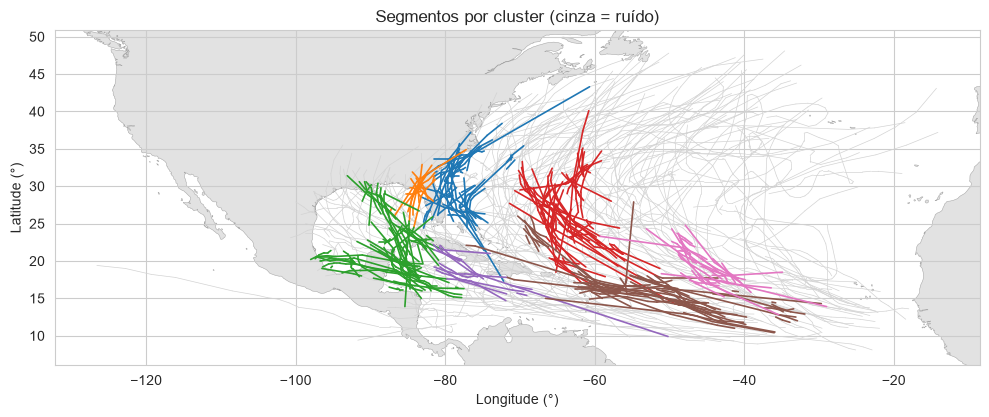

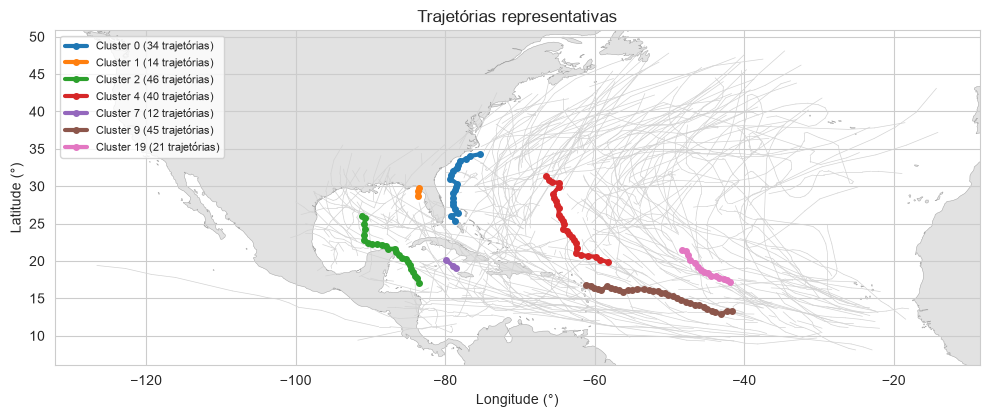

In [17]:
GAMMA_SUAVIZACAO = 50.0

trajetorias_representativas = {
    c: gerar_trajetoria_representativa(
        segmentos[segmentos["cluster"] == c],
        MIN_LNS_FINAL,
        GAMMA_SUAVIZACAO
    )
    for c in clusters_validos
}
cores_clusters = plt.cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(figsize=(10, 8))
for _, r in segmentos[segmentos["cluster"] == -1].iterrows():
    ax.plot(
        [r["lon_inicio"], r["lon_fim"]],
        [r["lat_inicio"], r["lat_fim"]],
        color="lightgray",
        lw=0.5,
        zorder=1
    )

for i, c in enumerate(clusters_validos):
    cor = cores_clusters[i % 10]
    for _, r in segmentos[segmentos["cluster"] == c].iterrows():
        ax.plot(
            [r["lon_inicio"], r["lon_fim"]],
            [r["lat_inicio"], r["lat_fim"]],
            color=cor,
            lw=1.2,
            zorder=2
        )

ax.set_title("Segmentos por cluster (cinza = ruído)")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_aspect("equal")
adicionar_mapa_base(ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
for _, r in segmentos[segmentos["cluster"] == -1].iterrows():
    ax.plot(
        [r["lon_inicio"], r["lon_fim"]],
        [r["lat_inicio"], r["lat_fim"]],
        color="lightgray",
        lw=0.5,
        zorder=1
    )

for i, c in enumerate(clusters_validos):
    cor = cores_clusters[i % 10]
    rt = trajetorias_representativas[c]

    if len(rt) > 0:
        lat_rt, lon_rt = xy_para_latlon(rt[:, 0], rt[:, 1], LAT_REF, LON_REF)
        n_traj = resumo_clusters.loc[
            resumo_clusters["cluster"] == c,
            "n_trajetorias"
        ].iloc[0]

        ax.plot(
            lon_rt,
            lat_rt,
            color=cor,
            lw=3,
            marker="o",
            ms=4,
            label=f"Cluster {c} ({n_traj} trajetórias)",
            zorder=3
        )

ax.set_title("Trajetórias representativas")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")
adicionar_mapa_base(ax)
plt.tight_layout()
plt.show()

**Leitura:** Os sete clusters correspondem a regiões e direções de deslocamento distintas: recurvatura ao longo da costa leste dos EUA (norte/nordeste), deslocamento para oeste em baixas latitudes (alísios). Padrões consistente com tempestades que recurvam leste-oeste para sul-norte e oeste-leste.

---
# 5. Avaliação da Qualidade dos Clusters

Com 7 clusters sobre 3.428 segmentos, avaliamos a qualidade com métricas internas:

| Seção | Métrica | O que mede |
|---|---|---|
| **5.1** | Silhouette adaptado | Coesão intra + separação inter, por segmento/cluster |
| **5.2** | Coesão, separação, Davies-Bouldin | Compacidade e distinção geométrica |

## 5.1 Silhouette adaptado

O **silhouette** $s(i)=\dfrac{b(i)-a(i)}{\max(a(i),b(i))}\in[-1,1]$ mede o quão bem um segmento está em seu cluster: $a(i)$ é a distância média intra-cluster, $b(i)$ a menor distância média ao cluster vizinho. Próximo de $+1$: bem alocado; perto de $0$: na fronteira; negativo: melhor no cluster vizinho.

**Adaptação:** Em vez de avaliar amostras em $\mathbb{R}^N$, a silhueta é aplicada aos segmentos usando `dist = d⊥+d∥+dθ`, e o ruído é ignorado. Mesmo sem satisfazer a desigualdade triangular, o *Silhouette* continua útil como indicador.

In [ ]:
# sub-matriz e rótulos apenas para segmentos clusterizados
mascara_clusterizados = rotulos >= 0
rotulos_sem_ruido = rotulos[mascara_clusterizados]
submat_clusters = matriz_dist[np.ix_(mascara_clusterizados, mascara_clusterizados)]

sil_por_segmento = silhouette_samples(submat_clusters, rotulos_sem_ruido, metric="precomputed")
sil_global = silhouette_score(submat_clusters, rotulos_sem_ruido, metric="precomputed")

print(f"Segmentos avaliados (clusterizados): {mascara_clusterizados.sum()} / {len(rotulos)}")
print(f"\nSilhouette global (s/ ruído): {sil_global:.4f}")
print(f"  Segmentos com s < 0 (potencialmente mal alocados): {(sil_por_segmento < 0).sum()} ({(sil_por_segmento < 0).mean():.1%})")
print(f"  Segmentos com s > 0.5 (bem alocados):              {(sil_por_segmento > 0.5).sum()} ({(sil_por_segmento > 0.5).mean():.1%})")
print()
print("Silhouette por cluster:")
for c in clusters_validos:
    idx_c = rotulos_sem_ruido == c
    sc = sil_por_segmento[idx_c].mean()
    neg = (sil_por_segmento[idx_c] < 0).mean()
    print(f"  cluster {c:2d}: s̄={sc:+.4f}  (neg={neg:.1%})  n={idx_c.sum()}")

Segmentos avaliados (clusterizados): 1018 / 3428

Silhouette global (s/ ruído): 0.3178
  Segmentos com s < 0 (potencialmente mal alocados): 202 (19.8%)
  Segmentos com s > 0.5 (bem alocados):              381 (37.4%)

Silhouette por cluster:
  cluster  0: s̄=+0.2214  (neg=14.8%)  n=182
  cluster  1: s̄=+0.6631  (neg=0.0%)  n=50
  cluster  2: s̄=+0.1686  (neg=29.4%)  n=248
  cluster  4: s̄=+0.5574  (neg=1.7%)  n=238
  cluster  7: s̄=+0.6954  (neg=0.0%)  n=44
  cluster  9: s̄=-0.0498  (neg=55.4%)  n=177
  cluster 19: s̄=+0.6816  (neg=0.0%)  n=79


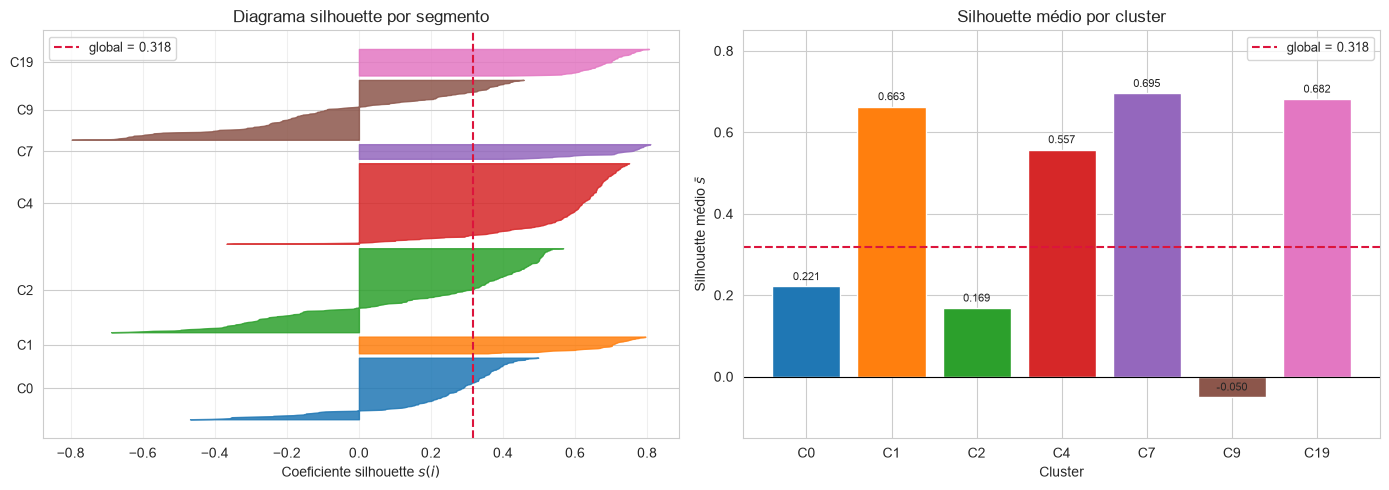

In [19]:
cores_clusters = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Diagrama silhouette ---
ax = axes[0]
y_pos = 0
ticks_y, labels_y = [], []
for k, c in enumerate(clusters_validos):
    idx_c = rotulos_sem_ruido == c
    s_c = np.sort(sil_por_segmento[idx_c])
    y_topo = y_pos + len(s_c)
    ax.fill_betweenx(np.arange(y_pos, y_topo), 0, s_c, color=cores_clusters[k % 10], alpha=0.85)
    ticks_y.append(y_pos + len(s_c) / 2)
    labels_y.append(f"C{c}")
    y_pos = y_topo + 12

ax.axvline(sil_global, color="crimson", ls="--", lw=1.5, label=f"global = {sil_global:.3f}")
ax.set_yticks(ticks_y)
ax.set_yticklabels(labels_y, fontsize=9)
ax.set_xlabel("Coeficiente silhouette $s(i)$")
ax.set_title("Diagrama silhouette por segmento")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)

# --- Silhouette médio por cluster (barras) ---
ax2 = axes[1]
sil_medios = [sil_por_segmento[rotulos_sem_ruido == c].mean() for c in clusters_validos]
barras = ax2.bar([f"C{c}" for c in clusters_validos], sil_medios,
                  color=[cores_clusters[k % 10] for k in range(len(clusters_validos))])
ax2.axhline(sil_global, color="crimson", ls="--", lw=1.5, label=f"global = {sil_global:.3f}")
ax2.axhline(0, color="k", lw=0.8)
for bar, val in zip(barras, sil_medios):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}",
              ha="center", va="bottom", fontsize=8)
ax2.set_xlabel("Cluster")
ax2.set_ylabel("Silhouette médio $\\bar{s}$")
ax2.set_title("Silhouette médio por cluster")
ax2.legend(fontsize=9)
ax2.set_ylim(-0.15, 0.85)

plt.tight_layout()
plt.show()

**Leitura:** O silhouette global de **0,318** indica separação moderada. **C7 (0,695)** e **C19 (0,682)**: clusters coesos e bem separados; **C1 (0,663)** e **C4 (0,557)**: boa separação, baixo diâmetro interno; **C9 (−0,050)**: silhouette negativo, sinal de cluster de fronteira sensível ao `eps`; **C0 (0,221)** e **C2 (0,169)**: separação modesta.

## 5.2 Coesão intra-cluster, separação inter-cluster e Davies-Bouldin

Decompomos explicitamente as duas propriedades que o silhouette combina, para cada cluster.

In [ ]:
tabela_coesao = calcular_coesao_clusters(matriz_dist, rotulos, clusters_validos)
mat_inter     = calcular_separacao_clusters(matriz_dist, rotulos, clusters_validos)
DB            = davies_bouldin_adaptado(tabela_coesao, mat_inter, clusters_validos)

print("Coesão intra-cluster:")
print(tabela_coesao.round(0).to_string(index=False))
print(f"\nÍndice Davies-Bouldin adaptado: {DB:.4f}")


Coesão intra-cluster:
 cluster  n_segmentos  dist_media_intra  diametro_km
       0          182             560.0       3221.0
       1           50             250.0        989.0
       2          248             823.0       2828.0
       4          238             706.0       3155.0
       7           44             381.0       1629.0
       9          177            1209.0       5345.0
      19           79             447.0       1585.0

Índice Davies-Bouldin adaptado: 1.0232  (menor = clusters mais compactos e separados)


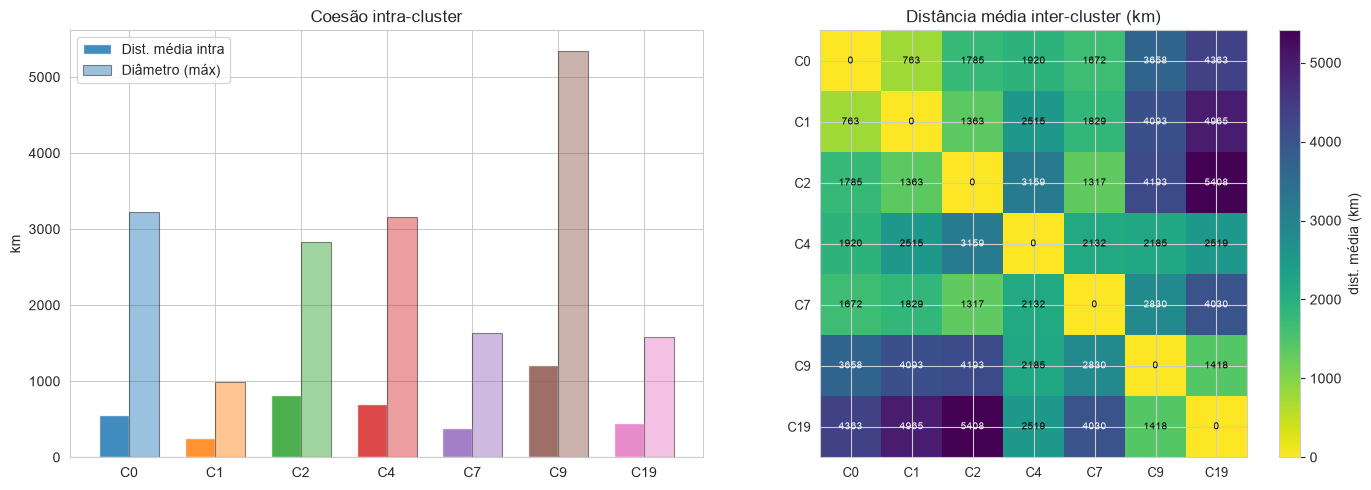

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: dist média intra vs diâmetro
ax = axes[0]
cl_labels = [f"C{c}" for c in clusters_validos]
x = np.arange(len(clusters_validos))
larg = 0.35
bars1 = ax.bar(x - larg / 2, tabela_coesao["dist_media_intra"], larg,
                label="Dist. média intra", color=[cores_clusters[k % 10] for k in range(len(clusters_validos))],
                alpha=0.85)
bars2 = ax.bar(x + larg / 2, tabela_coesao["diametro_km"], larg,
                label="Diâmetro (máx)", color=[cores_clusters[k % 10] for k in range(len(clusters_validos))],
                alpha=0.45, edgecolor="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cl_labels)
ax.set_ylabel("km")
ax.set_title("Coesão intra-cluster")
ax.legend()

# Heatmap: dist média inter-cluster
ax2 = axes[1]
im = ax2.imshow(mat_inter, cmap="viridis_r", vmin=0)
ax2.set_xticks(range(n_c)); ax2.set_yticks(range(n_c))
ax2.set_xticklabels(cl_labels, fontsize=9)
ax2.set_yticklabels(cl_labels, fontsize=9)
for i in range(n_c):
    for j in range(n_c):
        cor_txt = "white" if mat_inter[i, j] > mat_inter.max() * 0.5 else "black"
        ax2.text(j, i, f"{mat_inter[i, j]:.0f}", ha="center", va="center", fontsize=7, color=cor_txt)
plt.colorbar(im, ax=ax2, label="dist. média (km)")
ax2.set_title("Distância média inter-cluster (km)")

plt.tight_layout()
plt.show()

**Leitura:** **C1** e **C7** são os mais compactos (dist. intra média 250 km e 381 km); **C9** é o mais difuso (intra 1.209 km, diâmetro 5.345 km), o que explica seu silhouette negativo; **C0/C1** têm a menor distância inter-cluster (763 km médio, 23 km mínimo).

O Davies-Bouldin de **1,02** mostra que a separação inter-cluster está na mesma ordem de grandeza da coesão intra-cluster. Valor esperado para clusterização de trajetórias em grandes áreas com segmentos compridos.

---
# 6. Interpretação dos Agrupamentos

Cruzamos os 7 clusters geométricos com as variáveis meteorológicas do HURDAT2 (`wind_kt`, duração) e características espaciais (localização, orientação, velocidade translacional, sazonalidade), traduzindo a estrutura geométrica em **regimes interpretáveis**.

In [28]:
perfil_meteorologico = construir_perfil_meteorologico(segmentos, resumo_tempestades)

print(f"Registros (trajetória x cluster): {len(perfil_meteorologico)}")
print(f"Trajetórias únicas representadas: {perfil_meteorologico['id_tempestade'].nunique()}")
perfil_meteorologico.head()

Registros (trajetória x cluster): 212
Trajetórias únicas representadas: 142


,id_tempestade,cluster,n_segmentos_no_cluster,vento_medio_no_cluster,vento_max_no_cluster,vento_max_tempestade,duracao_dias,ano,velocidade_media_kmh,mes_pico
0,AL012004,0,7,59.166667,85,105,4.75,2004,15.466267,8
1,AL012005,2,1,46.000000,60,60,3.25,2005,21.834755,6
2,AL012006,1,5,44.666667,60,60,3.25,2006,19.321425,6
3,AL012010,2,6,45.861111,55,95,6.00,2010,12.762570,6
4,AL012012,0,6,39.166667,50,50,2.75,2012,9.270252,5


## 6.1 Mapa integrado: padrões geométricos e direções de deslocamento

O mapa combina: trajetórias cinza (todo o conjunto), segmentos coloridos por cluster, trajetórias representativas (linhas espessas) e setas indicando a direção preferencial de cada cluster (vetor de direção médio).

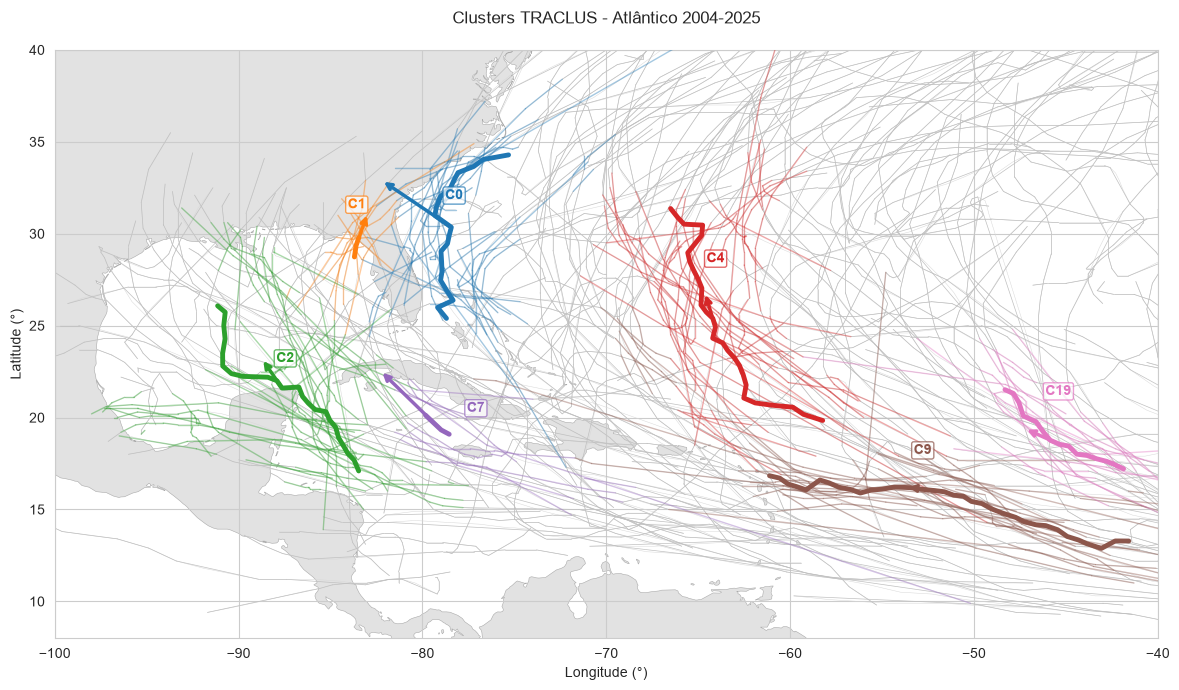

In [38]:
cores_clusters = plt.cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(figsize=(14, 7))

for _, g in dados.groupby("storm_id"):
    ax.plot(g["longitude"], g["latitude"], color="#d8d8d8", lw=0.35, zorder=1)

for _, r in segmentos[segmentos["cluster"] == -1].iterrows():
    ax.plot([r["lon_inicio"], r["lon_fim"]], [r["lat_inicio"], r["lat_fim"]],
            color="#c0c0c0", lw=0.5, zorder=2)

for k, c in enumerate(clusters_validos):
    cor = cores_clusters[k % 10]
    seg_c = segmentos[segmentos["cluster"] == c]

    for _, r in seg_c.iterrows():
        ax.plot([r["lon_inicio"], r["lon_fim"]], [r["lat_inicio"], r["lat_fim"]],
                color=cor, lw=1, alpha=0.4, zorder=3)

    rt = trajetorias_representativas[c]
    if len(rt) > 1:
        lat_rt, lon_rt = xy_para_latlon(rt[:, 0], rt[:, 1], LAT_REF, LON_REF)
        ax.plot(lon_rt, lat_rt, color=cor, lw=3.5, zorder=5)
        mid = len(rt) // 2
        if mid < len(rt) - 1:
            dlat = np.degrees((rt[mid + 1, 1] - rt[mid, 1]) / RAIO_TERRA_KM)
            lat_m, lon_m = xy_para_latlon(rt[mid, 0], rt[mid, 1], LAT_REF, LON_REF)
            dlon = np.degrees((rt[mid + 1, 0] - rt[mid, 0]) /
                               (RAIO_TERRA_KM * np.cos(np.radians(lat_m))))
            ax.annotate("", xy=(lon_m + dlon * 4, lat_m + dlat * 4), xytext=(lon_m, lat_m),
                        arrowprops=dict(arrowstyle="->", color=cor, lw=2.5), zorder=6)

    lat_c = (seg_c["lat_inicio"].mean() + seg_c["lat_fim"].mean()) / 2
    lon_c = (seg_c["lon_inicio"].mean() + seg_c["lon_fim"].mean()) / 2
    ax.text(lon_c, lat_c + 1.8, f"C{c}", color=cor, fontsize=10, fontweight="bold",
            ha="center", zorder=7,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=cor, alpha=0.7))

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Clusters TRACLUS - Atlântico 2004-2025\n")
ax.set_aspect("equal")
adicionar_mapa_base(ax)
ax.set_xlim(-100, -40)
ax.set_ylim(8, 40)
plt.tight_layout()
plt.show()

## 6.2 Intensidade e duração por cluster

Sistemas com padrões geométricos distintos têm intensidade e duração distintas? Comparamos `vento_medio_no_cluster` e `duracao_dias` entre os 7 clusters.

**Obs:** Como uma tempestade pode aparecer em múltiplos clusters, os grupos não são totalmente independentes.

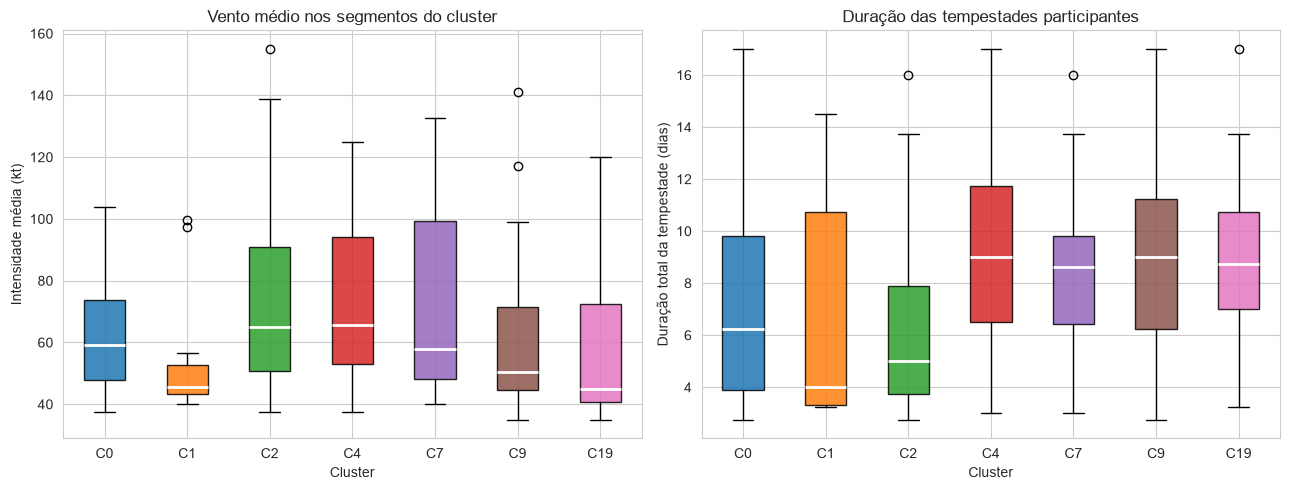

ANOVA - intensidade:  F=2.45,  p=0.0262
ANOVA - duração:      F=3.95,  p=0.0009


In [49]:
# Gráfico da ANOVA + análise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels_c = [f"C{c}" for c in clusters_validos]

for ax, coluna, ylabel, titulo in [
    (axes[0], "vento_medio_no_cluster", "Intensidade média (kt)",
     "Vento médio nos segmentos do cluster"),
    (axes[1], "duracao_dias", "Duração total da tempestade (dias)",
     "Duração das tempestades participantes"),
]:
    grupos = [perfil_meteorologico[perfil_meteorologico["cluster"] == c][coluna].dropna().values
              for c in clusters_validos]
    bp = ax.boxplot(grupos, tick_labels=labels_c, patch_artist=True, notch=False,
                    medianprops=dict(color="white", lw=2))
    for patch, k in zip(bp["boxes"], range(len(clusters_validos))):
        patch.set_facecolor(cores_clusters[k % 10])
        patch.set_alpha(0.85)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

grupos_vento = [perfil_meteorologico[perfil_meteorologico["cluster"] == c]
                ["vento_medio_no_cluster"].dropna().values for c in clusters_validos]
grupos_dur   = [perfil_meteorologico[perfil_meteorologico["cluster"] == c]
                ["duracao_dias"].dropna().values for c in clusters_validos]

F_v, p_v = stats.f_oneway(*grupos_vento)
F_d, p_d = stats.f_oneway(*grupos_dur)
print(f"ANOVA - intensidade:  F={F_v:.2f},  p={p_v:.4f}")
print(f"ANOVA - duração:      F={F_d:.2f},  p={p_d:.4f}")

**Leitura:** A ANOVA aponta diferenças significativas em intensidade ($F=2.45$, $p=0.026$) e duração ($F=3.95$, $p=0.001$) entre clusters.

**C2, C4, C7**: maiores intensidades médias (~73kt, ou ~135km/h);

**C1**: menor intensidade (~54kt ou ~100km/h) e menor duração (~4 dias);

**C4, C7, C9**: maiores durações medianas (~8 dias).

## 6.3 Velocidade translacional e sazonalidade

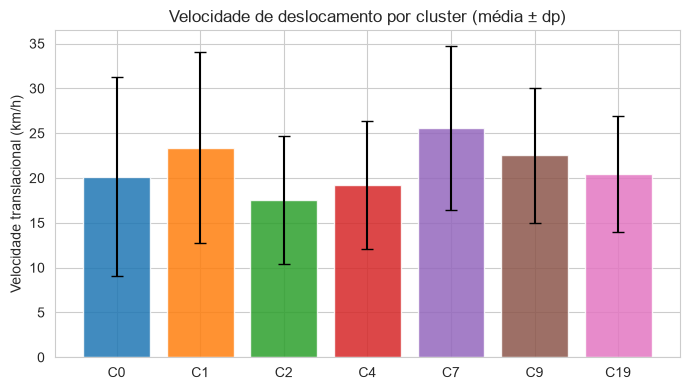

In [ ]:
# Gráfico de velocidade de translação média por cluster
fig, ax = plt.subplots(figsize=(7, 4))
vel_med = [
    perfil_meteorologico[perfil_meteorologico["cluster"] == c]["velocidade_media_kmh"].mean()
    for c in clusters_validos
]
vel_std = [
    perfil_meteorologico[perfil_meteorologico["cluster"] == c]["velocidade_media_kmh"].std()
    for c in clusters_validos
]
ax.bar(
    labels_c,
    vel_med,
    yerr=vel_std,
    color=[cores_clusters[k % 10] for k in range(len(clusters_validos))],
    capsize=4,
    alpha=0.85
)
ax.set_ylabel("Velocidade translacional (km/h)")
ax.set_title("Velocidade de deslocamento por cluster (média ± dp)")
plt.tight_layout()
plt.show()

**Leitura:** Os clusters **C7, C1 e C9** apresentam as maiores velocidades de deslocamento, indicando que suas trajetórias mais retilíneas em situações com corrente de direção dominante mais forte pode acelerar a translação do ciclone.

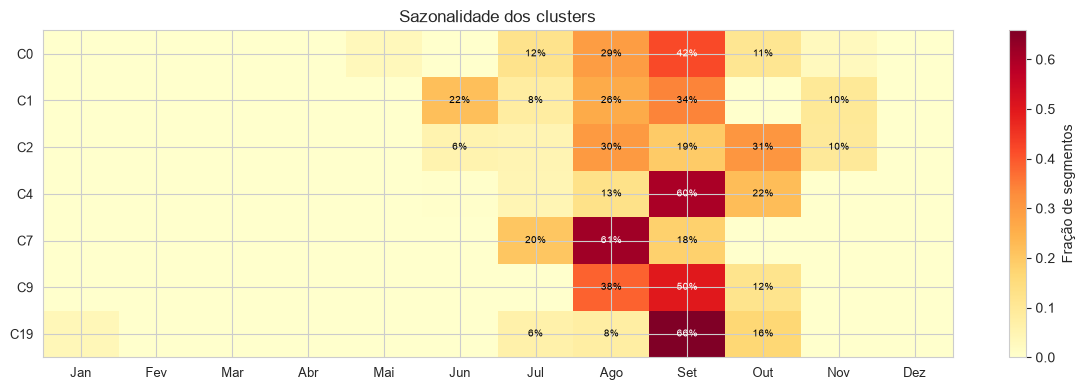

In [51]:
# Heatmap de sazonalidade
meses_nomes = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
                "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

mat_saz = np.zeros((len(clusters_validos), 12))
for k, c in enumerate(clusters_validos):
    seg_c = segmentos[segmentos["cluster"] == c].copy()
    seg_c["mes"] = pd.to_datetime(seg_c["datetime_inicio"]).dt.month
    for m in range(1, 13):
        mat_saz[k, m - 1] = (seg_c["mes"] == m).sum()
    soma = mat_saz[k].sum()
    if soma > 0:
        mat_saz[k] /= soma

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(mat_saz, cmap="YlOrRd", aspect="auto", vmin=0)
ax.set_xticks(range(12))
ax.set_xticklabels(meses_nomes, fontsize=9)
ax.set_yticks(range(len(clusters_validos)))
ax.set_yticklabels(labels_c, fontsize=9)
for k in range(len(clusters_validos)):
    for m in range(12):
        if mat_saz[k, m] > 0.05:
            ax.text(m, k, f"{mat_saz[k, m]:.0%}", ha="center", va="center",
                    fontsize=7, color="black" if mat_saz[k, m] < 0.4 else "white")
plt.colorbar(im, ax=ax, label="Fração de segmentos")
ax.set_title("Sazonalidade dos clusters")
plt.tight_layout()
plt.show()

**Leitura:** A fração de segmentos de todos os clusters se concentra em uma mesma janela, entre **junho e novembro**. Essa janela corresponde à temporada de furacões no Hemisfério Norte, causada pelo aumento da temperatura dos oceanos durante o verão e o outono.

## 6.4 Conclusão

Os 7 clusters revelam regiões e regimes de deslocamento distintos sem qualquer informação meteorológica como entrada, ou seja, a geometria do deslocamento já carrega informação sobre as características físicas dos ciclones. A distinção mais marcante é entre clusters de:

**baixas latitudes:** (C7, C9, C19: leste-oeste, alísios, fase inicial)

**latitudes médias:** (C0, C1, C4: norte/nordeste, recurvatura, sistemas mais intensos e duradouros).

# Referências